# KXNBAPTS Volume & Liquidity Analysis

How much volume do player points prop markets actually get?
Which tickers are liquid enough to market-make on?

In [1]:
import io
import re
from datetime import date, timedelta

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

s3 = boto3.client('s3')
BUCKET = 'prediction-markets-data'

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## 1. Load trade data

In [2]:
# Load TradeEvent silver data for recent dates
today = date(2026, 4, 25)
dates = [today - timedelta(days=i) for i in range(7)]

frames = []
total_files = 0
total_bytes = 0

# First pass: discover all keys
print('Discovering files...')
all_keys = []
for d in dates:
    prefix = f'silver/kalshi_ws/TradeEvent/date={d}/'
    pages = s3.get_paginator('list_objects_v2').paginate(Bucket=BUCKET, Prefix=prefix)
    day_keys = [o['Key'] for page in pages for o in page.get('Contents', [])]
    if day_keys:
        all_keys.extend((d, k) for k in day_keys)
        print(f'  {d}: {len(day_keys)} files')

print(f'\nDownloading {len(all_keys)} files...')
for i, (d, k) in enumerate(all_keys, 1):
    raw = s3.get_object(Bucket=BUCKET, Key=k)['Body'].read()
    total_bytes += len(raw)
    df = pd.read_parquet(io.BytesIO(raw))
    frames.append(df)
    if i % 25 == 0 or i == len(all_keys):
        print(f'  {i}/{len(all_keys)} files ({total_bytes / 1e6:.1f} MB)', end='\r')

print()

trades = pd.concat(frames, ignore_index=True)
trades['t_dt'] = pd.to_datetime(trades['t_receipt'], unit='s', utc=True)
trades['date'] = trades['t_dt'].dt.date

# Tag series
def get_series(ticker):
    m = re.match(r'(KXNBA\w+?)-', ticker)
    return m.group(1) if m else 'unknown'

trades['series'] = trades['market_ticker'].apply(get_series)

print(f'\nTotal trades: {len(trades):,}')
print(f'Date range: {trades["date"].min()} to {trades["date"].max()}')
print(f'\nTrades by series:')
for series, grp in trades.groupby('series'):
    print(f'  {series:15s}: {len(grp):>8,} trades, {grp["market_ticker"].nunique():>4} tickers')

Discovering files...
  2026-04-25: 857 files

  857/857 files (3.1 MB)

Total trades: 177,441
Date range: 2026-04-25 to 2026-04-25

Trades by series:
  KXNBAGAME      :  111,750 trades,   24 tickers
  KXNBAPTS       :    6,719 trades,  206 tickers
  KXNBASPREAD    :   31,457 trades,   78 tickers
  KXNBATOTAL     :   27,515 trades,   70 tickers


## 2. KXNBAPTS volume by ticker

In [3]:
pts = trades[trades['series'] == 'KXNBAPTS'].copy()
print(f'KXNBAPTS trades: {len(pts):,} across {pts["market_ticker"].nunique()} tickers\n')

# Volume per ticker
vol = pts.groupby('market_ticker').agg(
    n_trades=('size', 'count'),
    total_contracts=('size', 'sum'),
    avg_price=('price', 'mean'),
    first_trade=('t_dt', 'min'),
    last_trade=('t_dt', 'max'),
    n_yes=('side', lambda x: (x == 'yes').sum()),
    n_no=('side', lambda x: (x == 'no').sum()),
).sort_values('n_trades', ascending=False)

vol['yes_pct'] = (vol['n_yes'] / vol['n_trades'] * 100).round(1)
vol['duration_min'] = (vol['last_trade'] - vol['first_trade']).dt.total_seconds() / 60
vol['trades_per_hr'] = (vol['n_trades'] / (vol['duration_min'] / 60)).replace([np.inf], np.nan)

print(f'VOLUME DISTRIBUTION (per ticker):')
print(f'  Median trades/ticker: {vol["n_trades"].median():.0f}')
print(f'  Mean trades/ticker:   {vol["n_trades"].mean():.1f}')
print(f'  Max trades/ticker:    {vol["n_trades"].max()}')
print(f'  Tickers with 1 trade: {(vol["n_trades"] == 1).sum()}')
print(f'  Tickers with 5+ trades: {(vol["n_trades"] >= 5).sum()}')
print(f'  Tickers with 20+ trades: {(vol["n_trades"] >= 20).sum()}')
print(f'  Tickers with 50+ trades: {(vol["n_trades"] >= 50).sum()}')

print(f'\nTOP 30 TICKERS BY TRADE COUNT:')
print(f'{"Ticker":<55s}  {"Trades":>6s}  {"Contracts":>10s}  {"AvgPx":>6s}  '
      f'{"YES%":>5s}  {"Trades/hr":>10s}  {"Duration":>10s}')
print('-' * 115)
for ticker, row in vol.head(30).iterrows():
    dur = f'{row["duration_min"]:.0f}m' if pd.notna(row['duration_min']) else 'n/a'
    tph = f'{row["trades_per_hr"]:.1f}' if pd.notna(row['trades_per_hr']) else 'n/a'
    print(f'{ticker:<55s}  {row["n_trades"]:>6}  {row["total_contracts"]:>10}  '
          f'{row["avg_price"]:>6.1f}  {row["yes_pct"]:>5.1f}  {tph:>10s}  {dur:>10s}')

KXNBAPTS trades: 6,719 across 206 tickers

VOLUME DISTRIBUTION (per ticker):
  Median trades/ticker: 9
  Mean trades/ticker:   32.6
  Max trades/ticker:    518
  Tickers with 1 trade: 33
  Tickers with 5+ trades: 134
  Tickers with 20+ trades: 67
  Tickers with 50+ trades: 32

TOP 30 TICKERS BY TRADE COUNT:
Ticker                                                   Trades   Contracts   AvgPx   YES%   Trades/hr    Duration
-------------------------------------------------------------------------------------------------------------------
KXNBAPTS-26APR24SASPOR-SASSCASTLE5-30                       518       19824    66.8   60.4       245.7        127m
KXNBAPTS-26APR24SASPOR-PORDAVDIJA8-20                       485       11579    65.4   50.7       231.3        126m
KXNBAPTS-26APR24SASPOR-PORDAVDIJA8-25                       448       21783    38.4   59.4       219.6        122m
KXNBAPTS-26APR24SASPOR-SASDFOX4-20                          360       13691    36.9   53.9       172.0        126m


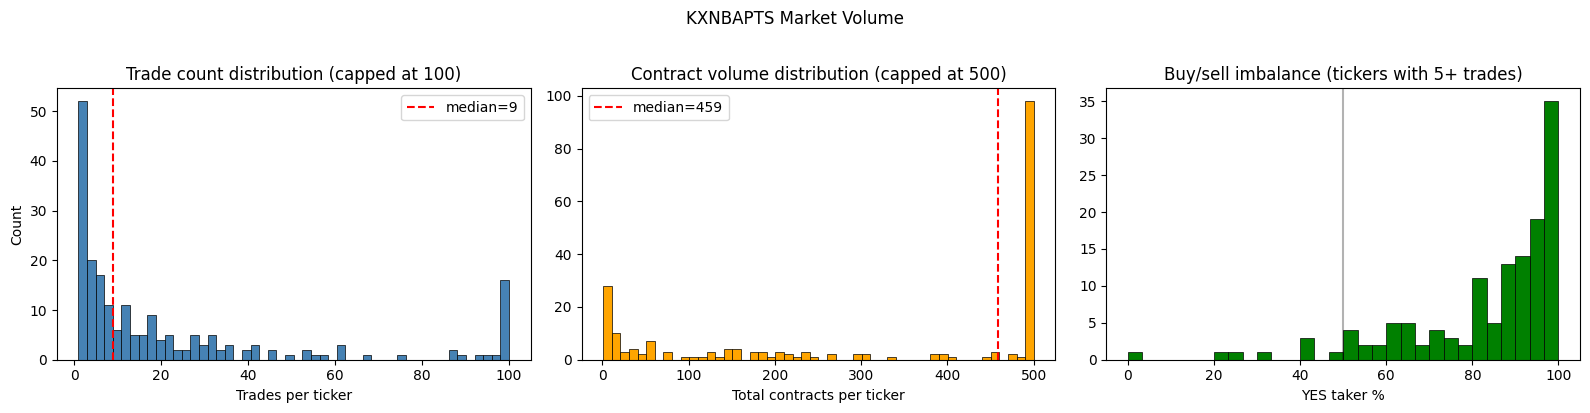

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Trades per ticker distribution
ax = axes[0]
ax.hist(vol['n_trades'].clip(upper=100), bins=50, color='steelblue', edgecolor='black', linewidth=0.5)
ax.axvline(vol['n_trades'].median(), color='red', linestyle='--', label=f'median={vol["n_trades"].median():.0f}')
ax.set_xlabel('Trades per ticker')
ax.set_ylabel('Count')
ax.set_title('Trade count distribution (capped at 100)')
ax.legend()

# Contracts per ticker
ax = axes[1]
ax.hist(vol['total_contracts'].clip(upper=500), bins=50, color='orange', edgecolor='black', linewidth=0.5)
ax.axvline(vol['total_contracts'].median(), color='red', linestyle='--',
           label=f'median={vol["total_contracts"].median():.0f}')
ax.set_xlabel('Total contracts per ticker')
ax.set_title('Contract volume distribution (capped at 500)')
ax.legend()

# YES% distribution
ax = axes[2]
ax.hist(vol[vol['n_trades'] >= 5]['yes_pct'], bins=30, color='green', edgecolor='black', linewidth=0.5)
ax.axvline(50, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('YES taker %')
ax.set_title('Buy/sell imbalance (tickers with 5+ trades)')

plt.suptitle('KXNBAPTS Market Volume', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 3. Volume by game and player

Parse the ticker structure: `KXNBAPTS-{date}{away}{home}-{team}{player}-{threshold}`

In [5]:
# Parse ticker components
def parse_pts_ticker(ticker):
    # KXNBAPTS-26APR25DENMIN-DENCBRAUN0-10
    parts = ticker.split('-')
    if len(parts) < 4:
        return None, None, None, None
    game = parts[1]  # 26APR25DENMIN
    player_part = parts[2]  # DENCBRAUN0
    threshold = parts[3]  # 10
    # Extract team (first 3 chars) from player part
    team = player_part[:3]
    player = player_part[3:]
    return game, team, player, int(threshold)

parsed = vol.reset_index()
parsed[['game', 'team', 'player', 'threshold']] = parsed['market_ticker'].apply(
    lambda t: pd.Series(parse_pts_ticker(t)))

# Volume by game
print('VOLUME BY GAME:')
game_vol = parsed.groupby('game').agg(
    tickers=('market_ticker', 'count'),
    total_trades=('n_trades', 'sum'),
    total_contracts=('total_contracts', 'sum'),
).sort_values('total_trades', ascending=False)

print(f'{"Game":<25s}  {"Tickers":>8s}  {"Trades":>8s}  {"Contracts":>10s}')
print('-' * 60)
for game, row in game_vol.iterrows():
    print(f'{game:<25s}  {row["tickers"]:>8}  {row["total_trades"]:>8}  {row["total_contracts"]:>10}')

# Volume by player (top 20)
print(f'\nTOP 20 PLAYERS BY TRADE COUNT:')
player_vol = parsed.groupby(['team', 'player']).agg(
    thresholds=('threshold', 'nunique'),
    total_trades=('n_trades', 'sum'),
    total_contracts=('total_contracts', 'sum'),
    avg_yes_pct=('yes_pct', 'mean'),
).sort_values('total_trades', ascending=False)

print(f'{"Team":>4s}  {"Player":<20s}  {"Thresholds":>10s}  {"Trades":>8s}  '
      f'{"Contracts":>10s}  {"YES%":>6s}')
print('-' * 70)
for (team, player), row in player_vol.head(20).iterrows():
    print(f'{team:>4s}  {player:<20s}  {row["thresholds"]:>10}  {row["total_trades"]:>8}  '
          f'{row["total_contracts"]:>10}  {row["avg_yes_pct"]:>6.1f}')

VOLUME BY GAME:
Game                        Tickers    Trades   Contracts
------------------------------------------------------------
26APR24SASPOR                    34      3688      140535
26APR25DETORL                    37      1649      175280
26APR25NYKATL                    40       496       45377
26APR25OKCPHX                    25       474       35319
26APR25DENMIN                    35       348       23112
26APR26LALHOU                    11        34        1115
26APR26CLETOR                    16        21         105
26APR26BOSPHI                     8         9         184

TOP 20 PLAYERS BY TRADE COUNT:
Team  Player                Thresholds    Trades   Contracts    YES%
----------------------------------------------------------------------
 POR  DAVDIJA8                     4.0     981.0     34920.0    46.3
 SAS  DFOX4                        4.0     723.0     23745.0    50.5
 SAS  SCASTLE5                     4.0     661.0     25912.0    47.5
 POR  JHOLIDAY5       

## 4. Volume by threshold level

Do higher or lower point thresholds get more volume?

VOLUME BY POINTS THRESHOLD:
 Threshold   Tickers    Trades   Contracts  Avg/ticker    YES%   AvgPx
----------------------------------------------------------------------
        10      35.0     944.0     69575.0        27.0    84.4    65.5
        15      50.0    1221.0     51052.0        24.4    81.6    50.5
        20      50.0    1957.0    125479.0        39.1    86.2    43.1
        25      34.0    1467.0     98920.0        43.1    88.8    39.2
        30      24.0     994.0     63374.0        41.4    86.9    26.0
        35      10.0     111.0     10821.0        11.1    85.9    19.3
        40       3.0      25.0      1806.0         8.3    78.4    15.4


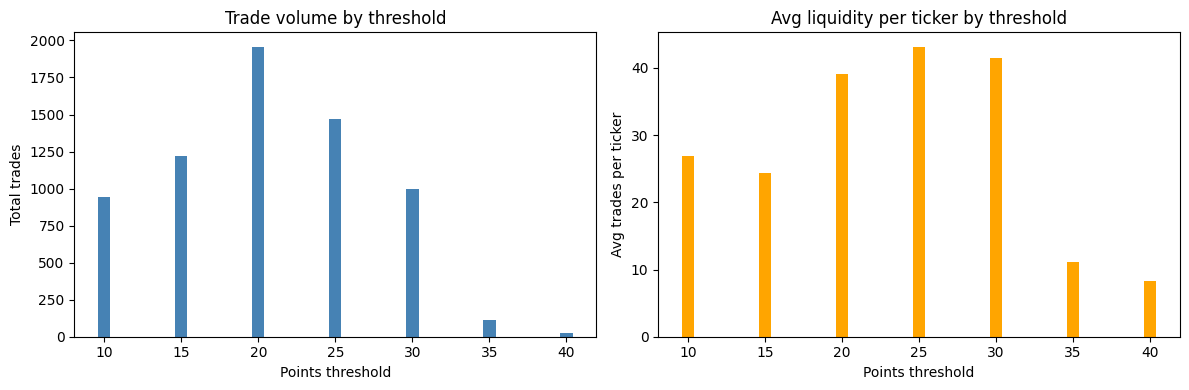

In [6]:
thresh_vol = parsed.groupby('threshold').agg(
    tickers=('market_ticker', 'count'),
    total_trades=('n_trades', 'sum'),
    total_contracts=('total_contracts', 'sum'),
    avg_trades_per_ticker=('n_trades', 'mean'),
    avg_yes_pct=('yes_pct', 'mean'),
    avg_price=('avg_price', 'mean'),
).sort_index()

print('VOLUME BY POINTS THRESHOLD:')
print(f'{"Threshold":>10s}  {"Tickers":>8s}  {"Trades":>8s}  {"Contracts":>10s}  '
      f'{"Avg/ticker":>10s}  {"YES%":>6s}  {"AvgPx":>6s}')
print('-' * 70)
for thresh, row in thresh_vol.iterrows():
    print(f'{thresh:>10}  {row["tickers"]:>8}  {row["total_trades"]:>8}  '
          f'{row["total_contracts"]:>10}  {row["avg_trades_per_ticker"]:>10.1f}  '
          f'{row["avg_yes_pct"]:>6.1f}  {row["avg_price"]:>6.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(thresh_vol.index, thresh_vol['total_trades'], color='steelblue')
ax.set_xlabel('Points threshold')
ax.set_ylabel('Total trades')
ax.set_title('Trade volume by threshold')

ax = axes[1]
ax.bar(thresh_vol.index, thresh_vol['avg_trades_per_ticker'], color='orange')
ax.set_xlabel('Points threshold')
ax.set_ylabel('Avg trades per ticker')
ax.set_title('Avg liquidity per ticker by threshold')

plt.tight_layout()
plt.show()

## 5. Intraday volume patterns

When during a game does trading happen?

HOURLY VOLUME (UTC):
 Hour    Trades   Contracts   Tickers
----------------------------------------
    3      1354       56785        58
    4      1541       68136        59
    5      1056       34916       107
    6       124       11567        53
    7        82        8883        45
    8        54        2525        37
    9        64        5586        31
   10        89        1547        60
   11        52        3074        28
   12       160       11217        67
   13       156       10249        61
   14       245       14895        81
   15       324       47141        86
   16       573       65463       100
   17       845       79043        90


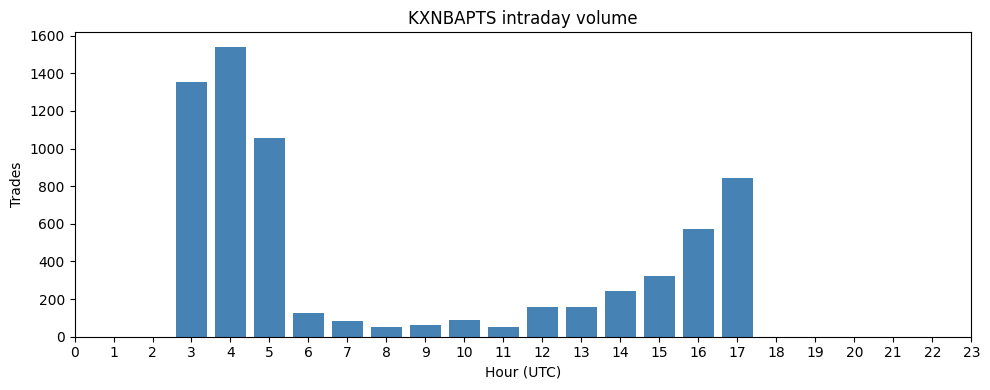

In [7]:
# Volume by hour (UTC)
pts_copy = pts.copy()
pts_copy['hour'] = pts_copy['t_dt'].dt.hour

hourly = pts_copy.groupby('hour').agg(
    trades=('size', 'count'),
    contracts=('size', 'sum'),
    tickers=('market_ticker', 'nunique'),
)

print('HOURLY VOLUME (UTC):')
print(f'{"Hour":>5s}  {"Trades":>8s}  {"Contracts":>10s}  {"Tickers":>8s}')
print('-' * 40)
for hour, row in hourly.iterrows():
    print(f'{hour:>5}  {row["trades"]:>8}  {row["contracts"]:>10}  {row["tickers"]:>8}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.index, hourly['trades'], color='steelblue')
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Trades')
ax.set_title('KXNBAPTS intraday volume')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

## 6. Inter-trade time

How long between consecutive trades on the same ticker?

INTER-TRADE TIME (tickers with 5+ trades):
  Observations: 6,442
  Median: 17.2s (0.3m)
  Mean:   670.9s (11.2m)
  P25:    0.0s
  P75:    199.4s (3.3m)
  P90:    1427.9s (23.8m)

YES→NO OFFSET TIME (time until offsetting flow):
  Observations: 3,914
  Median: 375.4s (6.3m)
  Mean:   3164.7s (52.7m)
  P75:    1913.3s (31.9m)
  P90:    11200.9s (186.7m)


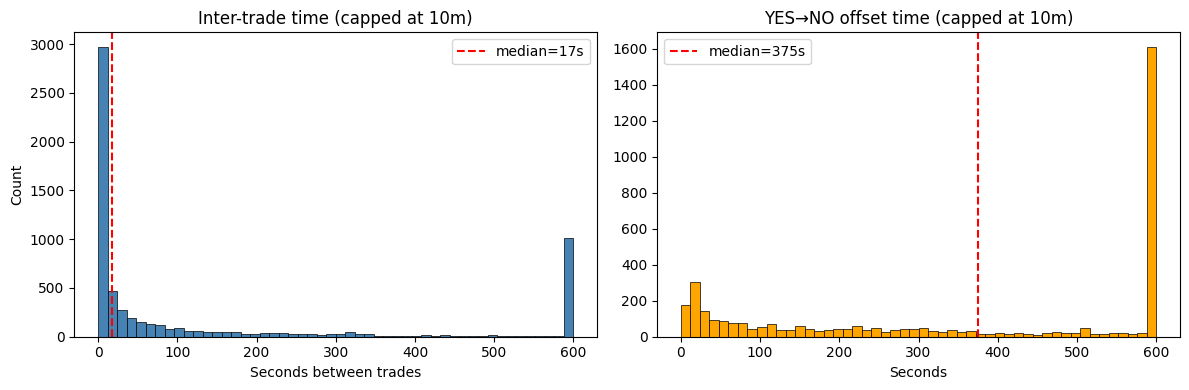

In [8]:
# Compute inter-trade times per ticker
itt_all = []
for ticker in vol[vol['n_trades'] >= 5].index:
    tk = pts[pts['market_ticker'] == ticker].sort_values('t_receipt')
    diffs = tk['t_receipt'].diff().dropna()
    itt_all.extend(diffs.tolist())

itt = pd.Series(itt_all)
print(f'INTER-TRADE TIME (tickers with 5+ trades):')
print(f'  Observations: {len(itt):,}')
print(f'  Median: {itt.median():.1f}s ({itt.median()/60:.1f}m)')
print(f'  Mean:   {itt.mean():.1f}s ({itt.mean()/60:.1f}m)')
print(f'  P25:    {itt.quantile(0.25):.1f}s')
print(f'  P75:    {itt.quantile(0.75):.1f}s ({itt.quantile(0.75)/60:.1f}m)')
print(f'  P90:    {itt.quantile(0.90):.1f}s ({itt.quantile(0.90)/60:.1f}m)')

# Same but split by YES→NO offset time
offset_times = []
for ticker in vol[vol['n_trades'] >= 5].index:
    tk = pts[pts['market_ticker'] == ticker].sort_values('t_receipt')
    yes_trades = tk[tk['side'] == 'yes']['t_receipt'].values
    no_trades = tk[tk['side'] == 'no']['t_receipt'].values
    # For each YES trade, find time to next NO trade
    for yt in yes_trades:
        future_no = no_trades[no_trades > yt]
        if len(future_no) > 0:
            offset_times.append(future_no[0] - yt)

if offset_times:
    ot = pd.Series(offset_times)
    print(f'\nYES→NO OFFSET TIME (time until offsetting flow):')
    print(f'  Observations: {len(ot):,}')
    print(f'  Median: {ot.median():.1f}s ({ot.median()/60:.1f}m)')
    print(f'  Mean:   {ot.mean():.1f}s ({ot.mean()/60:.1f}m)')
    print(f'  P75:    {ot.quantile(0.75):.1f}s ({ot.quantile(0.75)/60:.1f}m)')
    print(f'  P90:    {ot.quantile(0.90):.1f}s ({ot.quantile(0.90)/60:.1f}m)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(itt.clip(upper=600), bins=50, color='steelblue', edgecolor='black', linewidth=0.5)
ax.axvline(itt.median(), color='red', linestyle='--', label=f'median={itt.median():.0f}s')
ax.set_xlabel('Seconds between trades')
ax.set_ylabel('Count')
ax.set_title('Inter-trade time (capped at 10m)')
ax.legend()

if offset_times:
    ax = axes[1]
    ax.hist(ot.clip(upper=600), bins=50, color='orange', edgecolor='black', linewidth=0.5)
    ax.axvline(ot.median(), color='red', linestyle='--', label=f'median={ot.median():.0f}s')
    ax.set_xlabel('Seconds')
    ax.set_title('YES→NO offset time (capped at 10m)')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Compare with other series

How does KXNBAPTS volume compare to game/spread/total markets?

In [9]:
print('VOLUME BY SERIES:')
print(f'{"Series":<15s}  {"Tickers":>8s}  {"Trades":>8s}  {"Contracts":>10s}  '
      f'{"Med trades/tk":>13s}  {"Avg size":>9s}')
print('-' * 75)

for series in ['KXNBAPTS', 'KXNBAGAME', 'KXNBASPREAD', 'KXNBATOTAL',
               'KXNBAREB', 'KXNBAAST', 'KXNBA3PT']:
    s = trades[trades['series'] == series]
    if s.empty:
        continue
    tk_counts = s.groupby('market_ticker')['size'].count()
    print(f'{series:<15s}  {s["market_ticker"].nunique():>8}  {len(s):>8,}  '
          f'{s["size"].sum():>10,}  {tk_counts.median():>13.0f}  '
          f'{s["size"].mean():>9.1f}')

VOLUME BY SERIES:
Series            Tickers    Trades   Contracts  Med trades/tk   Avg size
---------------------------------------------------------------------------
KXNBAPTS              206     6,719     421,027              9       62.7
KXNBAGAME              24   111,750  33,465,835           1108      299.5
KXNBASPREAD            78    31,457   6,120,729             29      194.6
KXNBATOTAL             70    27,515   5,078,439             26      184.6
